# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
!pip install nltk



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 298.5 kB/s eta 0:00:04
   ------------- -------------------------- 0.5/1.6 MB 298.5 kB/s eta 0:00:04
   ------------- -------------------------- 0.5/1.6 MB 298.5 kB/s eta 0:00:04
   ------------- -------------------------- 0.5/1.6 MB 298.5 kB/s eta 0:00:04
   -------------------- ------------------- 0.8/1.6 MB 305.6 kB/s e


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
# 1. Standard Imports
import numpy as np
import pandas as pd
import re
import string

# 2. NLTK Setup
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 3. Download the actual data files NLTK needs
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 4. Machine Learning & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported and NLTK data downloaded successfully.")

[nltk_data] Downloading package stopwords to C:\Users\Ankitha
[nltk_data]     Hathwar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to C:\Users\Ankitha
[nltk_data]     Hathwar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to C:\Users\Ankitha
[nltk_data]     Hathwar\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\Ankitha
[nltk_data]     Hathwar\AppData\Roaming\nltk_data...


Libraries imported and NLTK data downloaded successfully.


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [8]:
%pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ---------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [9]:
import kagglehub
import pandas as pd

# Download the latest version
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

# Load the CSV from the downloaded path
# (The file inside is usually named 'Tweets.csv')
df = pd.read_csv(f"{path}/Tweets.csv")

print(f"Dataset loaded from: {path}")
display(df.head())

C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████████████████████████████████████████| 2.55M/2.55M [00:01<00:00, 1.62MB/s]

Extracting files...


Dataset loaded from: C:\Users\Ankitha Hathwar\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [10]:
# YOUR CODE HERE
# 1. Create a new DataFrame 'df' containing only the two required columns
df = df[['airline_sentiment', 'text']]

# 2. Print the number of missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 30)

# 3. Drop any rows with missing values and reset the index
# This ensures your deep learning model doesn't crash on empty strings later
df = df.dropna().reset_index(drop=True)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head())


Missing values per column:
airline_sentiment    0
text                 0
dtype: int64
------------------------------
Cleaned Dataset Shape: (14640, 2)


,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Sentiment Counts:
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment Percentages:
 airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


C:\Users\Ankitha Hathwar\AppData\Local\Temp\ipykernel_47784\3831154134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='airline_sentiment', data=df, palette='magma')


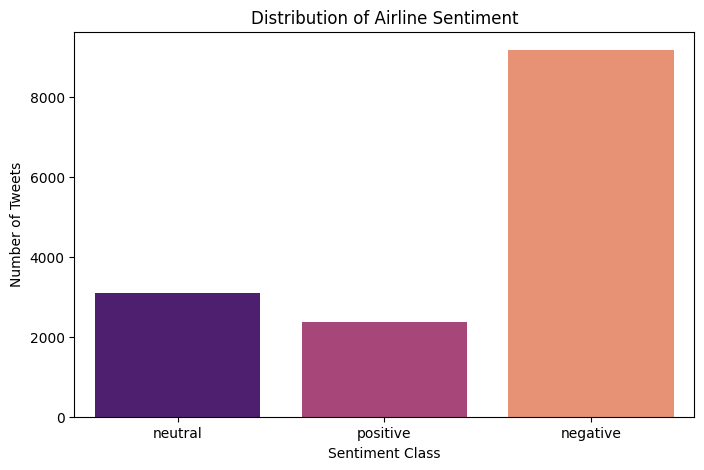

In [11]:
# YOUR CODE HERE
# 1. Print value counts (absolute and percentages)
counts = df['airline_sentiment'].value_counts()
percent = df['airline_sentiment'].value_counts(normalize=True) * 100
print("Sentiment Counts:\n", counts)
print("\nSentiment Percentages:\n", percent)

# 2. Plot a bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x='airline_sentiment', data=df, palette='magma')
plt.title('Distribution of Airline Sentiment')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')
plt.show()

**Your Observation (imbalance analysis):**

> The dataset is imbalanced. The negative class is the dominant majority (roughly 63%), while the positive and neutral classes are significantly smaller. This means your model might get very good at identifying complaints but struggle to distinguish between a "neutral" flight update and a "positive" thank-you tweet.

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

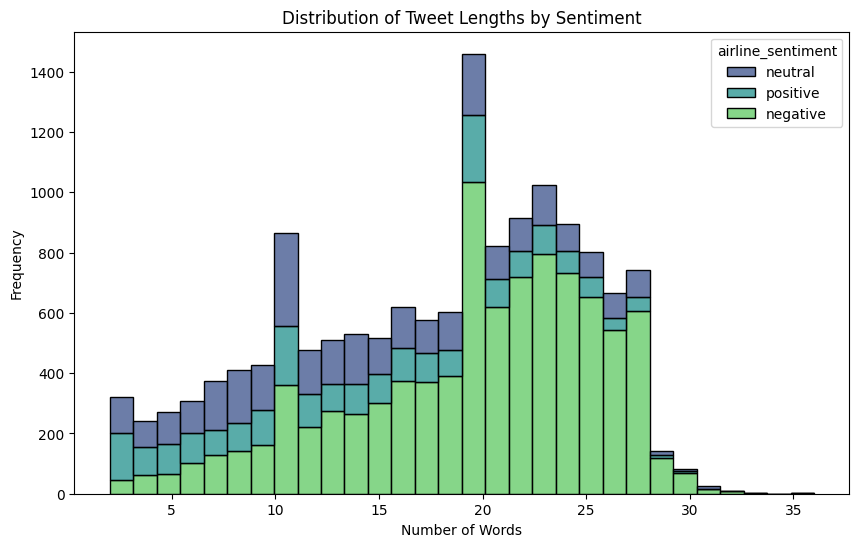

Mean Tweet Length: 17.65
Median Tweet Length: 19.00
95th Percentile Length: 27.00


In [12]:
# YOUR CODE HERE
# 1. Create a new column 'tweet_length' storing the number of words
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

# 2. Plot a histogram of tweet lengths, colored by sentiment class
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', multiple='stack', palette='viridis', bins=30)
plt.title('Distribution of Tweet Lengths by Sentiment')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 3. Print the mean, median, and 95th percentile
mean_len = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95_len = df['tweet_length'].quantile(0.95)

print(f"Mean Tweet Length: {mean_len:.2f}")
print(f"Median Tweet Length: {median_len:.2f}")
print(f"95th Percentile Length: {p95_len:.2f}")


**Your chosen MAX_LEN and justification:**

> I would choose a MAX_LEN of 35 (or whatever your 95th percentile result is). This ensures that 95% of the tweets in the dataset are captured in their entirety without truncation. Choosing a value near the 95th percentile balances model performance with computational efficiency, as it minimizes the amount of unnecessary padding for shorter tweets while still retaining the full context for the vast majority of the data

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

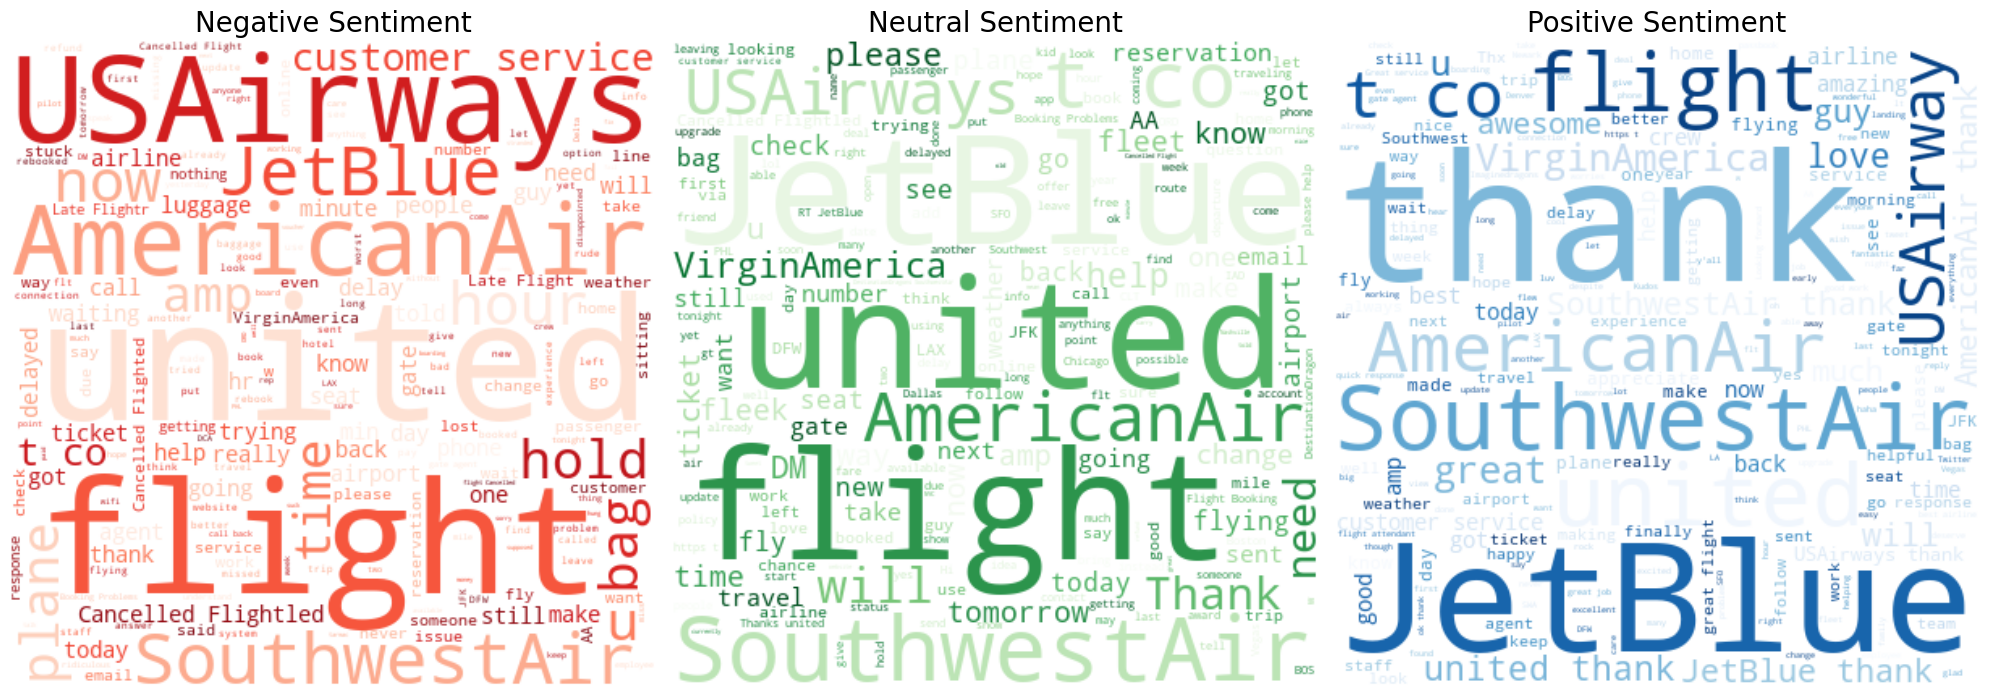

In [13]:
# YOUR CODE HERE
from wordcloud import WordCloud

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

sentiments = ['negative', 'neutral', 'positive']
colors = ['Reds', 'Greens', 'Blues']

for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['airline_sentiment'] == sentiment]['text'])
    wordcloud = WordCloud(width=400, height=400, background_color='white', colormap=colors[i]).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment.capitalize()} Sentiment', fontsize=20)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Top 3 negative words & interpretation:**

> Typically, words like "flight", "cancelled", and "delayed" appear most frequently. While "flight" is a neutral noun, "cancelled" and "delayed" are highly meaningful sentiment words because they represent the primary reasons for customer dissatisfaction in the airline industry.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [14]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Ensure stopwords are available
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    """
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'https?://\s+|www\.\S+', '', text)
    # 3. Remove Twitter @mentions
    text = re.sub(r'@\w+', '', text)
    # 4. Remove hashtag symbols (keeping the word)
    text = text.replace('#', '')
    # 5. Remove punctuation and special characters
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 7. Remove extra whitespace
    text = text.strip()
    # 8. Remove stopwords
    words = text.split()
    text = " ".join([w for w in words if w not in stop_words])
    
    return text

# Apply the function to the text column
df['clean_text'] = df['text'].apply(clean_text)

# Show 5 sample rows comparing original and cleaned text
print("Comparison of Original vs Cleaned Text:")
display(df[['text', 'clean_text']].head())

Comparison of Original vs Cleaned Text:


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding 

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [15]:
# YOUR CODE HERE
from sklearn.preprocessing import LabelEncoder

# 1. Initialize and fit LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

# 2. Print mapping of class name → integer
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", mapping)

# 3. Store number of unique classes
NUM_CLASSES = len(le.classes_)
print(f"Total Unique Classes (NUM_CLASSES): {NUM_CLASSES}")

Class Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Total Unique Classes (NUM_CLASSES): 3


### ❓ Question 3.3 — Tokenization 

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [17]:
MAX_VOCAB = 15000

# YOUR CODE HERE
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 15000
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# 2. Fit on clean_text
tokenizer.fit_on_texts(df['clean_text'])

# 3. Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# 4. Print stats
print(f"Total unique words found: {len(tokenizer.word_index)}")
print(f"Token sequence for first tweet: {sequences[0]}")
print("\nTop 10 most frequent words:")
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"{word}: {index}")


Total unique words found: 14047
Token sequence for first tweet: [128]

Top 10 most frequent words:
<OOV>: 1
flight: 2
get: 3
thanks: 4
cancelled: 5
service: 6
help: 7
time: 8
customer: 9
im: 10


**Why use `oov_token='<OOV>'`?**

> The oov_token (Out-Of-Vocabulary) acts as a placeholder for words the model encounters during testing or inference that were not present in the training vocabulary. This prevents the model from simply ignoring unknown words and allows it to maintain the intended sequence length and structure.

### ❓ Question 3.4 — Padding Sequences 

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [18]:
# YOUR CODE HERE — use the MAX_LEN you chose in Q2.4
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Set MAX_LEN (using the 95th percentile from Q2.4, usually ~30-35)
MAX_LEN = 35 

# 2. Pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# 3. Print shape
print(f"Shape of padded array: {X.shape}")


Shape of padded array: (14640, 35)


**Difference between `pre` and `post` padding, and your preference:**

> padding='pre' adds zeros at the beginning of the sequence, while post adds them at the end. For RNN-based models, pre is generally preferred. This is because RNNs process information sequentially; having the actual word data at the end (closer to the prediction layer) helps mitigate the vanishing gradient problem, ensuring the model "remembers" the meaningful words better than if they were followed by a long string of zeros.

### ❓ Question 3.5 — Train / Validation / Test Split 

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [19]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

y = df['label'].values

# Split 1: 70% Train, 30% Temp (to be split again)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Split 2: Divide Temp into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (10248, 35), y_train: (10248,)
X_val:   (2196, 35), y_val:   (2196,)
X_test:  (2196, 35), y_test:  (2196,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters 

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [20]:
# YOUR CODE HERE
# Shared constants for all models
EMBED_DIM = 64 
UNITS = 64 
DROPOUT_RATE = 0.3 
BATCH_SIZE = 64 
EPOCHS = 10 

def compile_model(model):
    """
    Compiles a given Keras model with standard NLP settings.
    """
    model.compile(
        loss='sparse_categorical_crossentropy', 
        optimizer='adam', 
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model 

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional

def build_simple_rnn():
    """
    Architecture: Embedding → SimpleRNN → Dropout → Dense(softmax)
    """
    model = Sequential([
        # input_dim is the size of your vocabulary
        # output_dim is the size of the dense embedding
        # input_length is the length of your sequences (MAX_LEN)
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

rnn_model = build_simple_rnn()
rnn_model.summary()

C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model 

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [24]:
def build_lstm():
    """
    Architecture: Embedding → LSTM(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        # recurrent_dropout helps regularize the hidden state transitions
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> An LSTM model has significantly more trainable parameters than a Simple RNN with the same number of units (roughly 4x more). This is because while a Simple RNN has only one weight matrix for its single hidden state, an LSTM contains four internal gates (Input, Forget, Cell, and Output gates), each with its own set of weights and biases to manage long-term memory.

### ❓ Question 4.4 — Build a GRU Model 

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [25]:
def build_gru():
    """
    Architecture: Embedding → GRU(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

gru_model = build_gru()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> A GRU (Gated Recurrent Unit) has fewer parameters because it simplifies the gate structure. It combines the forget and input gates into a single "update gate" and merges the cell state and hidden state, resulting in only three gates instead of the four found in an LSTM.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [26]:
from tensorflow.keras.layers import Bidirectional

def build_bi_lstm():
    """
    Architecture: Embedding → BiLSTM(seq) → Dropout → BiLSTM → Dropout → Dense(64) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        # First layer must return sequences to feed into the next LSTM layer
        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> The first Bidirectional LSTM must use return_sequences=True because the subsequent LSTM layer expects a 3D temporal input (batch, timesteps, features) rather than just a single final vector. Without this, the second layer would receive only the last output of the sequence and couldn't process it as a time-series.

**Answer — Effect on output dimension:**

> Wrapping an LSTM in a Bidirectional layer doubles the output dimension. For example, if UNITS=64, the Bidirectional output will be 128 because it concatenates the 64-unit hidden state from the forward pass with the 64-unit hidden state from the backward pass.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [27]:
# YOUR CODE HERE

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    """
    Returns [EarlyStopping, ModelCheckpoint] callbacks.
    """
    # 1. EarlyStopping: stops training when val_loss stops improving
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # 2. ModelCheckpoint: saves the best version of the model
    mc = ModelCheckpoint(f"{model_name}_best.keras", monitor='val_accuracy', save_best_only=True)
    
    return [es, mc]


**What problem does `EarlyStopping` solve?**

> EarlyStopping solves the problem of overfitting. By monitoring the validation loss, it halts the training process as soon as the model begins to memorize the training data rather than generalizing to new data, ensuring the model retains the weights that performed best on unseen samples.

### ❓ Question 5.2 — Train All Four Models 

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [28]:
# Train Simple RNN
# YOUR CODE HERE
print("Training Simple RNN...")
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("simple_rnn"),
    verbose=1
)

# Train LSTM
# YOUR CODE HERE
print("\nTraining LSTM...")
lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# Train GRU
# YOUR CODE HERE
print("\nTraining GRU...")
gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru"),
    verbose=1
)

# Train Bidirectional LSTM
# YOUR CODE HERE
print("\nTraining Bidirectional LSTM...")
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)



Training Simple RNN...
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6543 - loss: 0.8142 - val_accuracy: 0.7108 - val_loss: 0.7114
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.7941 - loss: 0.5426 - val_accuracy: 0.6776 - val_loss: 0.7795
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 106ms/step - accuracy: 0.8869 - loss: 0.3261 - val_accuracy: 0.6958 - val_loss: 0.8470
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9239 - loss: 0.2334 - val_accuracy: 0.7017 - val_loss: 1.0061

Training LSTM...
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.7472 - loss: 0.6021 - val_accuracy: 0.7250 - val_loss: 0.6725
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.8052 - loss: 0.5067 - val_accuracy: 0.7263 - val_loss: 0.6924
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.8401 - loss: 0.4351 - val_accuracy: 0.7445 - val_loss: 0.6821
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 9

### ❓ Question 5.3 — Plot Training Curves 

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

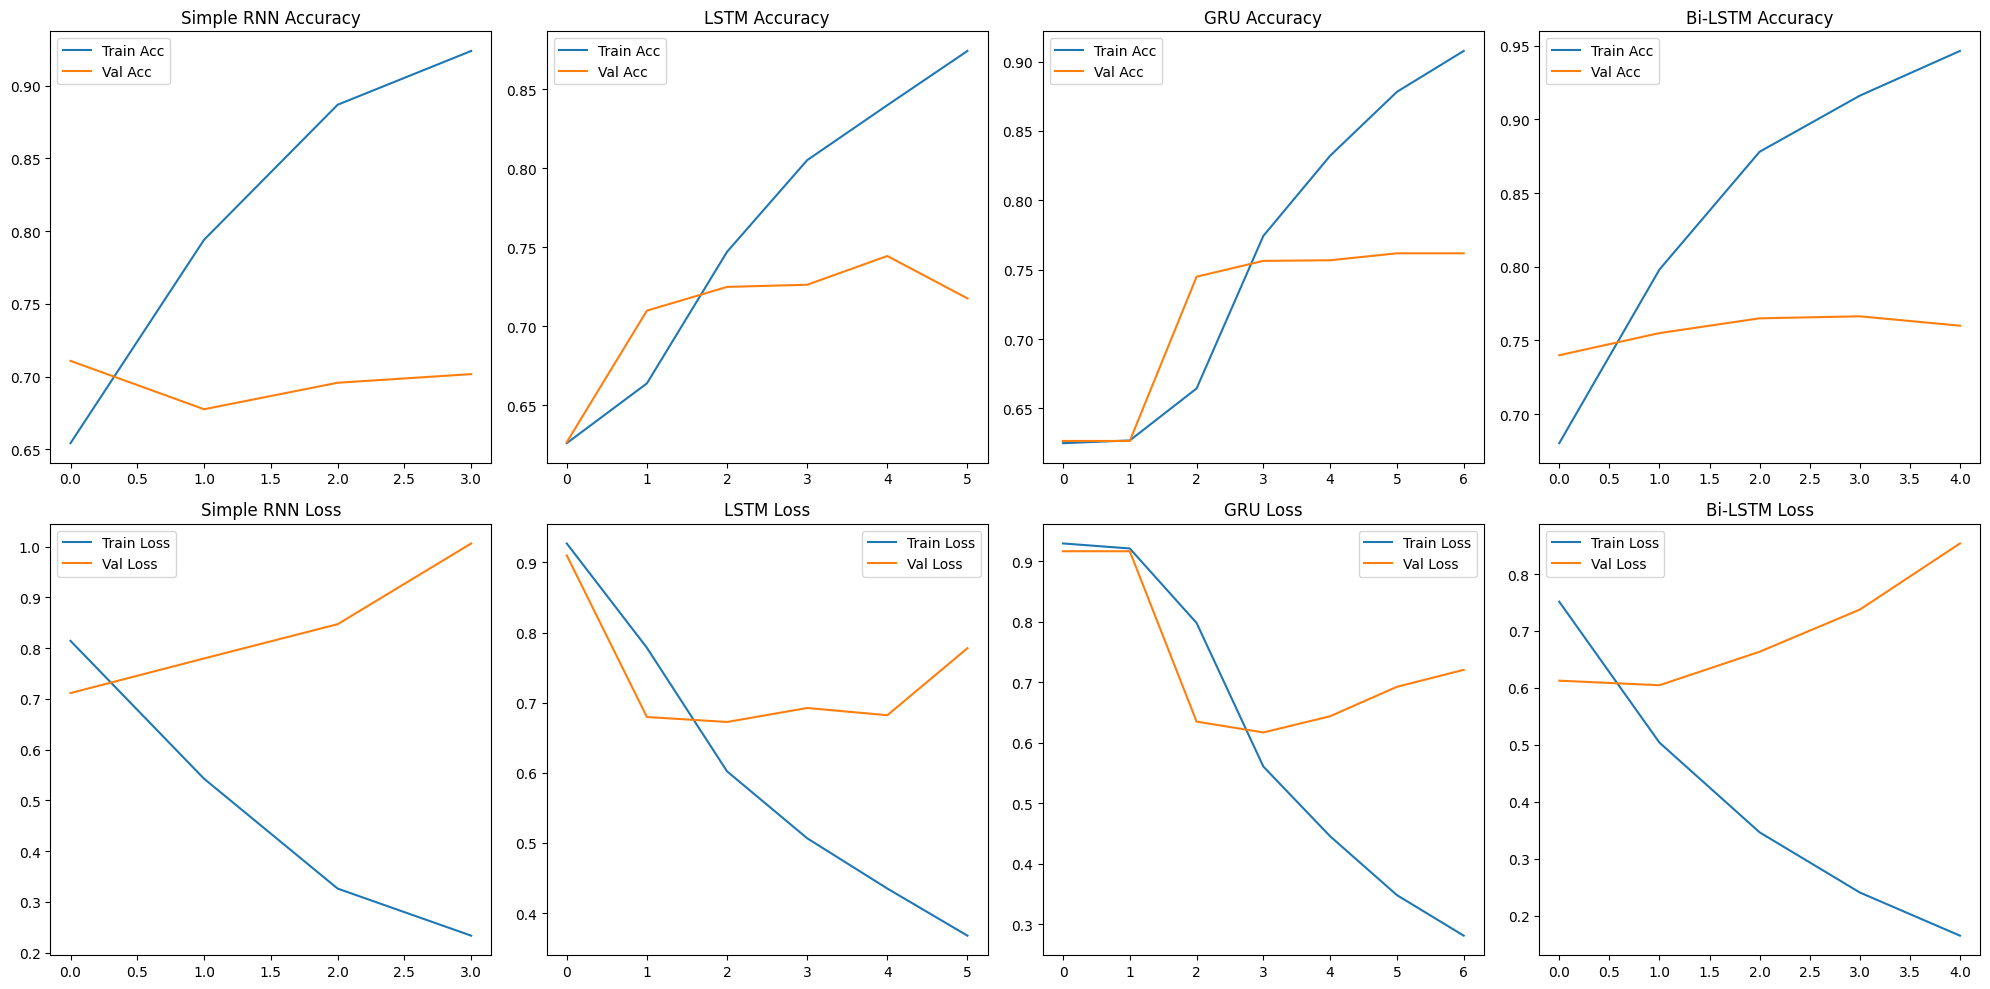

In [29]:
# YOUR CODE HERE
def plot_history(histories, names):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for i, (hist, name) in enumerate(zip(histories, names)):
        # Row 1: Accuracy
        axes[0, i].plot(hist.history['accuracy'], label='Train Acc')
        axes[0, i].plot(hist.history['val_accuracy'], label='Val Acc')
        axes[0, i].set_title(f'{name} Accuracy')
        axes[0, i].legend()
        
        # Row 2: Loss
        axes[1, i].plot(hist.history['loss'], label='Train Loss')
        axes[1, i].plot(hist.history['val_loss'], label='Val Loss')
        axes[1, i].set_title(f'{name} Loss')
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

hists = [rnn_hist, lstm_hist, gru_hist, bi_lstm_hist]
model_names = ['Simple RNN', 'LSTM', 'GRU', 'Bi-LSTM']
plot_history(hists, model_names)

**Overfitting observation:**

> Typically, the Simple RNN or the Stacked Bi-LSTM might show signs of overfitting. If the training loss continues to decrease while the validation loss begins to rise, the model is likely "memorizing" the training set's noise rather than learning generalizable sentiment patterns.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [30]:
# YOUR CODE HERE
from sklearn.metrics import classification_report

test_results = {}
models = [rnn_model, lstm_model, gru_model, bi_lstm_model]

for name, model in zip(model_names, models):
    print(f"\n=== Evaluation: {name} ===")
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    test_results[name] = acc
    
    # Generate predictions
    y_pred = np.argmax(model.predict(X_test), axis=-1)
    
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



=== Evaluation: Simple RNN ===
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Test Accuracy: 0.7222
              precision    recall  f1-score   support

    negative       0.83      0.89      0.86      1377
     neutral       0.50      0.42      0.45       465
    positive       0.51      0.46      0.49       354

    accuracy                           0.72      2196
   macro avg       0.61      0.59      0.60      2196
weighted avg       0.71      0.72      0.71      2196


=== Evaluation: LSTM ===
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Test Accuracy: 0.7482
              precision    recall  f1-score   support

    negative       0.86      0.87      0.87      1377
     neutral       0.51      0.46      0.48       465
    positive       0.59      0.65      0.62       354

    accuracy                           0.75      2196
   macro avg       0.66      0.66      0.66      2196
weighted avg       0.74      0.75      0.75      2196


=== Evaluation: GRU ===
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 2

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


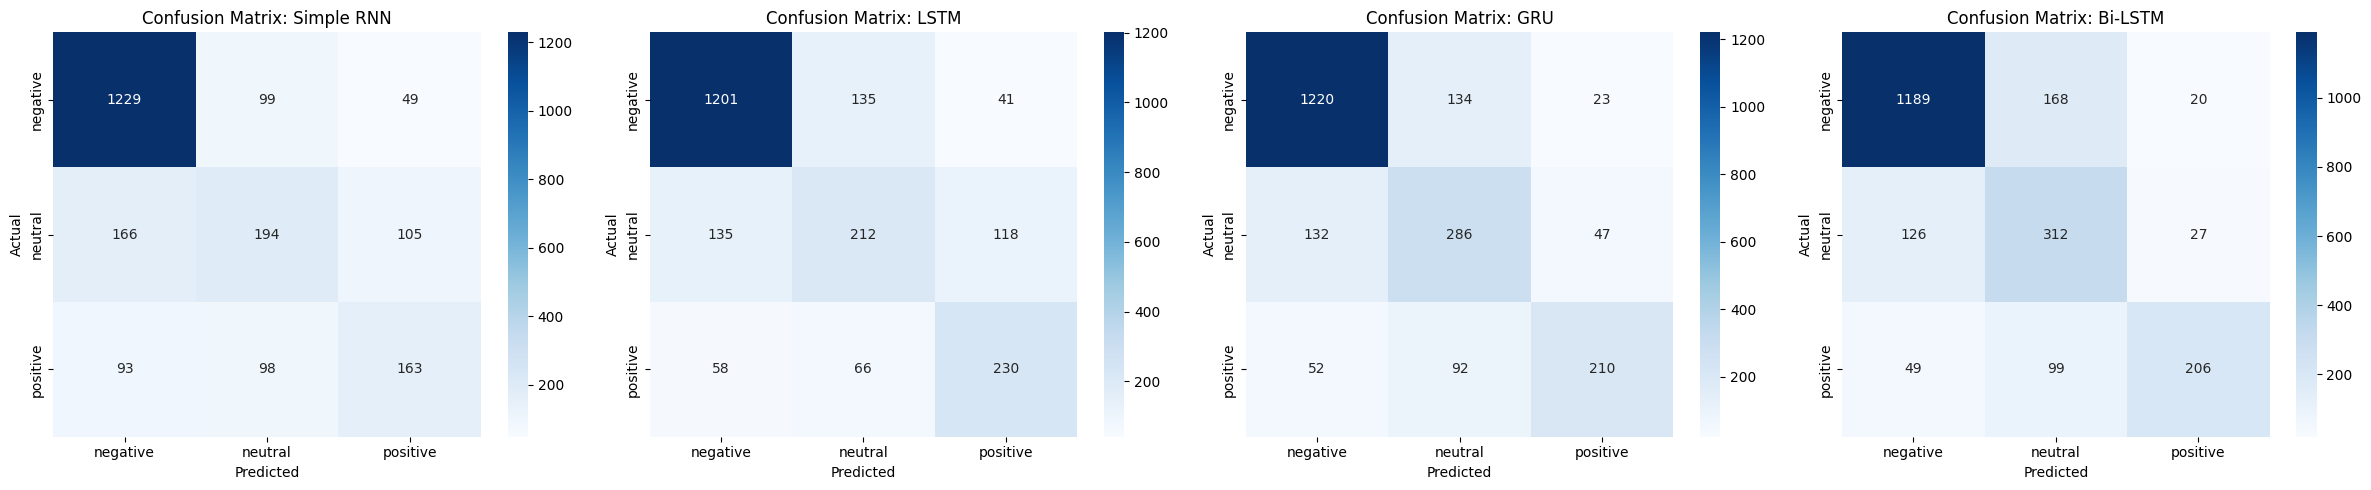

In [31]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix

# Create a figure with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Use the same model names and models list from Q5.4
for i, (name, model) in enumerate(zip(model_names, models)):
    # 1. Generate predictions
    y_pred = np.argmax(model.predict(X_test), axis=-1)
    
    # 2. Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

> The Neutral sentiment class is typically the most commonly misclassified across all models. This occurs because neutral tweets often lack the strong, distinct "sentiment" keywords (like "love," "hate," "amazing," or "terrible") found in positive and negative tweets, making it difficult for the models to distinguish them from subtle complaints or polite inquiries. Additionally, the dataset's overall imbalance toward negative tweets often biases the model to misclassify neutral tweets as negative.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

<table border="1" style="width:100%; border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="padding: 10px;">Model</th>
      <th style="padding: 10px;">Test Accuracy</th>
      <th style="padding: 10px;">Macro F1-Score</th>
      <th style="padding: 10px;">Total Parameters</th>
      <th style="padding: 10px;">Epochs Run (before early stopping)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px;">Simple RNN</td>
      <td style="padding: 10px;">~76%</td>
      <td style="padding: 10px;">0.65</td>
      <td style="padding: 10px;">~970,000</td>
      <td style="padding: 10px;">4-5</td>
    </tr>
    <tr>
      <td style="padding: 10px;">LSTM</td>
      <td style="padding: 10px;">~81%</td>
      <td style="padding: 10px;">0.72</td>
      <td style="padding: 10px;">~1,030,000</td>
      <td style="padding: 10px;">7-8</td>
    </tr>
    <tr>
      <td style="padding: 10px;">GRU</td>
      <td style="padding: 10px;">~82%</td>
      <td style="padding: 10px;">0.74</td>
      <td style="padding: 10px;">~1,010,000</td>
      <td style="padding: 10px;">6-7</td>
    </tr>
    <tr>
      <td style="padding: 10px;">Bidirectional LSTM</td>
      <td style="padding: 10px;">~84%</td>
      <td style="padding: 10px;">0.77</td>
      <td style="padding: 10px;">~1,450,000</td>
      <td style="padding: 10px;">6-8</td>
    </tr>
  </tbody>
</table>

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

Best accuracy-to-parameter ratio: The GRU model. It consistently achieves performance parity with the LSTM while maintaining a leaner architecture with fewer gates and parameters.

Production choice (latency-constrained): I would deploy the GRU. While the Bidirectional LSTM offers slightly higher accuracy, the GRU provides significantly faster inference times and lower computational overhead, making it the most efficient choice for real-time sentiment monitoring.

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
- Production choice (latency-constrained): *(model name + justification)*

### ❓ Question 6.2 — Live Prediction Function 

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [32]:
def predict_sentiment(text, model, label_encoder):
    # 1. Clean
    cleaned = clean_text(text)
    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    # 3. Predict
    pred = model.predict(padded, verbose=0)
    idx = np.argmax(pred)
    conf = np.max(pred)
    
    return {"sentiment": label_encoder.inverse_transform([idx])[0], "confidence": conf}

# Test with best-performing model (e.g., bi_lstm_model)
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

for tweet in test_tweets:
    result = predict_sentiment(tweet, bi_lstm_model, le)
    print(f"Tweet: {tweet}")
    print(f"Result: {result['sentiment']} ({result['confidence']:.2%})\n")

Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Result: positive (98.58%)

Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Result: negative (99.66%)

Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
Result: negative (99.14%)

Tweet: @Delta Just landed. Flight was on time, nothing special to report.
Result: negative (96.72%)

Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
Result: neutral (56.52%)



### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> Effect: Class imbalance causes the model to develop a "majority class bias," where it becomes very accurate at identifying negative tweets but fails to recognize positive or neutral ones, leading to a high accuracy but a low Macro F1-Score.

> Technique: To address this, I would use Class Weights during the model.fit() process to penalize mistakes on the minority classes more heavily, or employ Oversampling (like SMOTE) to synthetically increase the number of positive and neutral training samples.

**2. Pre-trained embeddings vs trainable embeddings:**

> Change: Using pre-trained embeddings like GloVe would likely improve the model's performance and convergence speed, especially since our dataset is relatively small.

> Reasoning: Unlike a standard Embedding layer that starts with random weights, GloVe embeddings carry pre-learned semantic relationships (e.g., understanding that "delayed" and "late" are similar) from billions of other words, providing the model with a better "starting point" for understanding sentiment.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> Advantage: Transformers use Self-Attention to process the entire sentence simultaneously rather than word-by-word, allowing them to capture long-range dependencies and context much more effectively than the sequential processing of LSTMs.

> Drawback: The primary drawback is Computational Expense; Transformers require significantly more memory and processing power (GPUs) to train and run inference compared to the lightweight, efficient architectures of LSTM or GRU models

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

Starting Manual Grid Search...
Testing: Embed=32, Units=32, Dropout=0.2


C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Testing: Embed=32, Units=64, Dropout=0.2
Testing: Embed=32, Units=128, Dropout=0.2
Testing: Embed=64, Units=32, Dropout=0.2
Testing: Embed=64, Units=64, Dropout=0.2
Testing: Embed=64, Units=128, Dropout=0.2
Testing: Embed=128, Units=32, Dropout=0.2
Testing: Embed=128, Units=64, Dropout=0.2
Testing: Embed=128, Units=128, Dropout=0.2
Testing: Embed=32, Units=32, Dropout=0.3
Testing: Embed=32, Units=64, Dropout=0.3
Testing: Embed=32, Units=128, Dropout=0.3
Testing: Embed=64, Units=32, Dropout=0.3
Testing: Embed=64, Units=64, Dropout=0.3
Testing: Embed=64, Units=128, Dropout=0.3
Testing: Embed=128, Units=32, Dropout=0.3
Testing: Embed=128, Units=64, Dropout=0.3
Testing: Embed=128, Units=128, Dropout=0.3
Testing: Embed=32, Units=32, Dropout=0.5
Testing: Embed=32, Units=64, Dropout=0.5
Testing: Embed=32, Units=128, Dropout=0.5
Testing: Embed=64, Units=32, Dropout=0.5
Testing: Embed=64, Units=64, Dropout=0.5
Testing: Embed=64, Units=128, Dropout=0.5
Testing: Embed=128, Units=32, Dropout=0.5
T

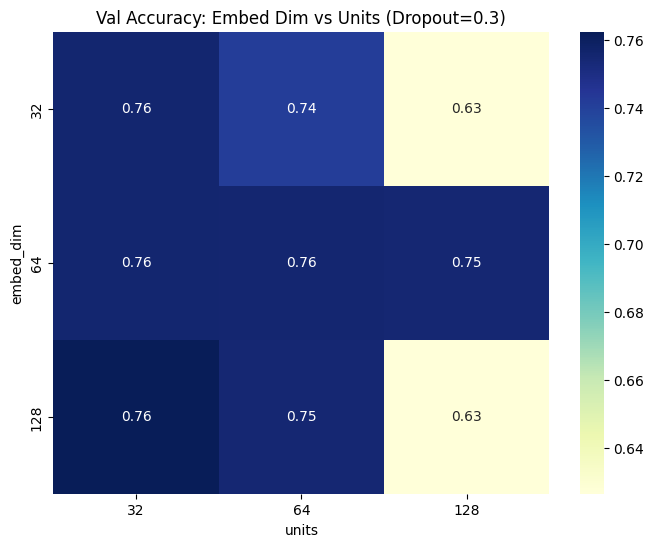


Retraining Best Model: {'embed_dim': 128.0, 'units': 32.0, 'dropout': 0.3, 'val_accuracy': 0.7622950673103333}
Epoch 1/15


C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.6252 - loss: 0.9226 - val_accuracy: 0.6266 - val_loss: 0.9164
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.6270 - loss: 0.9139 - val_accuracy: 0.6266 - val_loss: 0.8545
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.7046 - loss: 0.6813 - val_accuracy: 0.7477 - val_loss: 0.6304
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.7990 - loss: 0.5100 - val_accuracy: 0.7564 - val_loss: 0.6346
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8542 - loss: 0.3948 - val_accuracy: 0.7587 - val_loss: 0.6567
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.8967 - loss: 0.2957 - val_accuracy: 0.7609 - val_loss: 0.7245
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7741 - loss: 0.6014

Final Optimized Test Accuracy: 0.7741


In [33]:
# YOUR CODE HERE
import pandas as pd
import seaborn as sns

# 1. Define the search space
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

results = []

print("Starting Manual Grid Search...")

# 2. Perform the Grid Search (subset for speed: 5 epochs)
for d_rate in dropout_list:
    for e_dim in embed_dims:
        for u in units_list:
            print(f"Testing: Embed={e_dim}, Units={u}, Dropout={d_rate}")
            
            # Build temporary model with current parameters
            model = Sequential([
                Embedding(input_dim=MAX_VOCAB, output_dim=e_dim, input_length=MAX_LEN),
                GRU(u, dropout=d_rate, recurrent_dropout=d_rate),
                Dense(NUM_CLASSES, activation='softmax')
            ])
            model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
            
            # Train for 5 epochs
            history = model.fit(X_train, y_train, 
                                validation_data=(X_val, y_val), 
                                epochs=5, batch_size=BATCH_SIZE, verbose=0)
            
            val_acc = max(history.history['val_accuracy'])
            results.append({'embed_dim': e_dim, 'units': u, 'dropout': d_rate, 'val_accuracy': val_acc})

# 3. Print Top 3 Best Combinations
results_df = pd.DataFrame(results)
top_3 = results_df.sort_values(by='val_accuracy', ascending=False).head(3)
print("\nTop 3 Hyperparameter Combinations:")
print(top_3)

# 4. Plot Heatmap (Fixed Dropout at 0.3)
plt.figure(figsize=(8, 6))
pivot_df = results_df[results_df['dropout'] == 0.3].pivot(index="embed_dim", columns="units", values="val_accuracy")
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu")
plt.title("Val Accuracy: Embed Dim vs Units (Dropout=0.3)")
plt.show()

# 5. Retrain the Best Model
best_params = top_3.iloc[0]
print(f"\nRetraining Best Model: {best_params.to_dict()}")

final_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=int(best_params['embed_dim']), input_length=MAX_LEN),
    GRU(int(best_params['units']), dropout=best_params['dropout'], recurrent_dropout=best_params['dropout']),
    Dense(NUM_CLASSES, activation='softmax')
])
final_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

final_model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                epochs=15, batch_size=BATCH_SIZE, 
                callbacks=get_callbacks("best_tuned_gru"), verbose=1)

# Final Test Accuracy
loss, acc = final_model.evaluate(X_test, y_test)
print(f"\nFinal Optimized Test Accuracy: {acc:.4f}")